In [2]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [3]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
    make_animation,
    metrics_grid,
    plot_grid,
    plot_ball_behavior,
    plot_all_trajectories,
)
from sklearn.cluster import KMeans
import plotly.express as px
from src.classify import classify_trajectories

In [4]:
model = "bruss"
ds_id = "stat_an"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df = ds.df
df = expand_json_column(df, "original_point", "op", True)
df = expand_json_column(df, "initial_condition", "ic", True)
df = classify_trajectories(df)
df["ratio_b_a"] = df["B"] / df["A"]
df["ic"] = df["ic"].apply(lambda x: str(x))

In [6]:
def plot_histograms_by_params(df, metric='mean_deviation'):
    param_cols = ['A', 'B', 'Du', 'Dv']
    grouped = df.groupby(param_cols)

    for params, group in grouped:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=group, x='pix', hue='ic', kde=False, bins=20, multiple='stack')
        plt.title(f'A={params[0]:.2f}, B={params[1]:.2f}, Du={params[2]:.2f}, Dv={params[3]:.2f}')
        plt.xlabel(metric)
        plt.ylabel('Count')
        plt.legend(title='Initial Condition')
        plt.tight_layout()
        plt.show()

In [7]:
def plot_pixel_histograms_by_ic(df, ds, pixels: list, idx):
    param_cols = ['A', 'B', 'Du', 'Dv']
    unique_param_sets = df[param_cols].drop_duplicates()
    param_set = unique_param_sets.iloc[idx].to_dict()

    mask = (df[param_cols] == pd.Series(param_set)).all(axis=1)
    subset = df[mask]

    if subset.empty:
        print("No data for selected parameter set.")
        return

    fig, axes = plt.subplots(1, len(pixels), figsize=(5 * len(pixels), 4))
    if len(pixels) == 1:
        axes = [axes]

    for ax, (x, y) in zip(axes, pixels):
        values = [
            {'value': ds.get_data(i)[50, :, 0::2][x, y], 'ic': ic}
            for i, ic in zip(subset.index, subset['ic'])
        ]
        plot_df = pd.DataFrame(values)
        sns.histplot(data=plot_df, x='value', hue='ic', bins=30, multiple='stack', ax=ax)
        ax.set_title(f'Pixel ({x}, {y})')
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')

    plt.suptitle(f'Parameter set: {param_set}', fontsize=12)
    plt.tight_layout()
    plt.show()


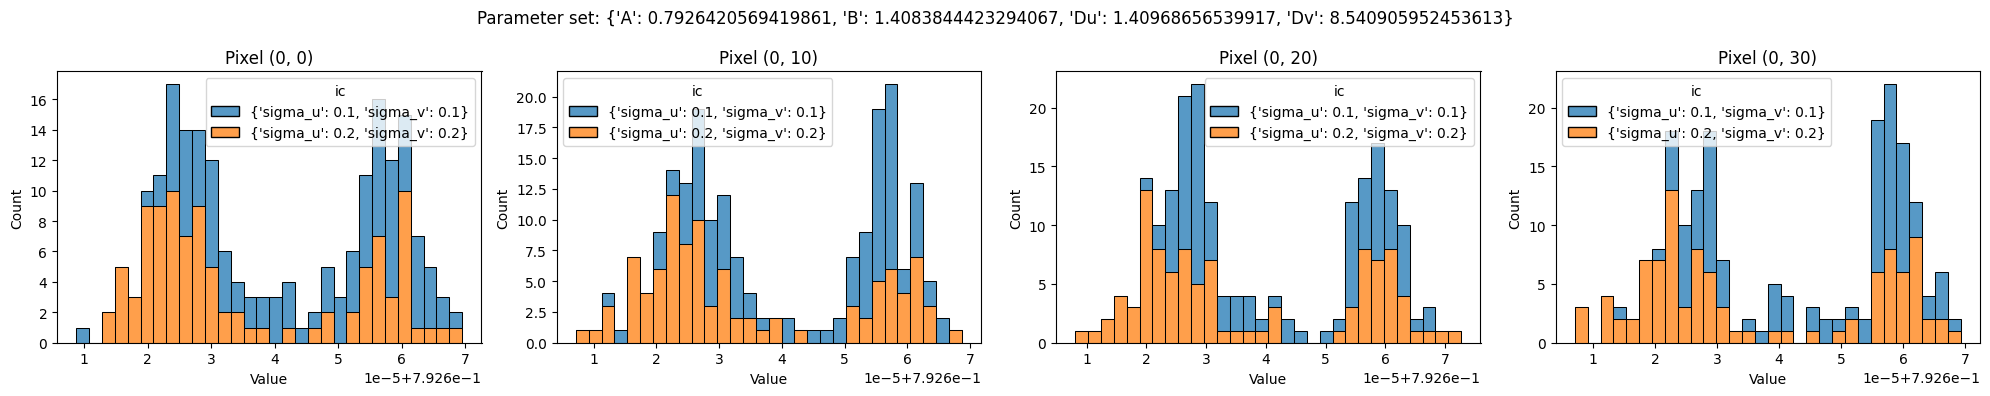

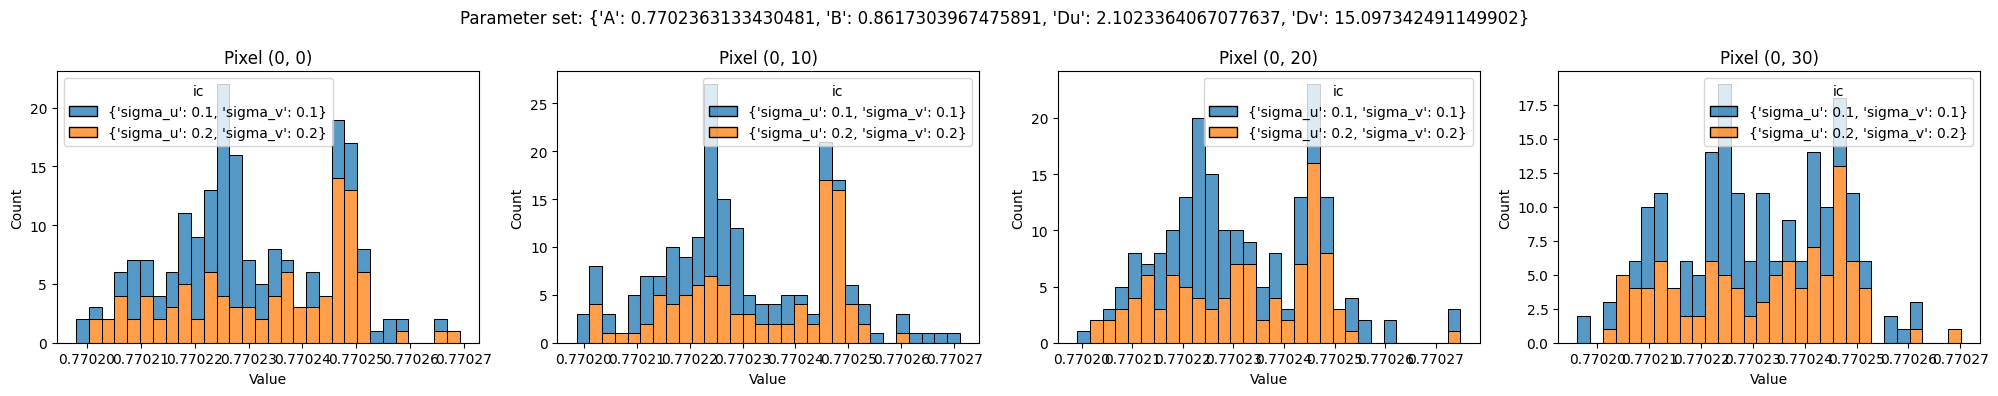

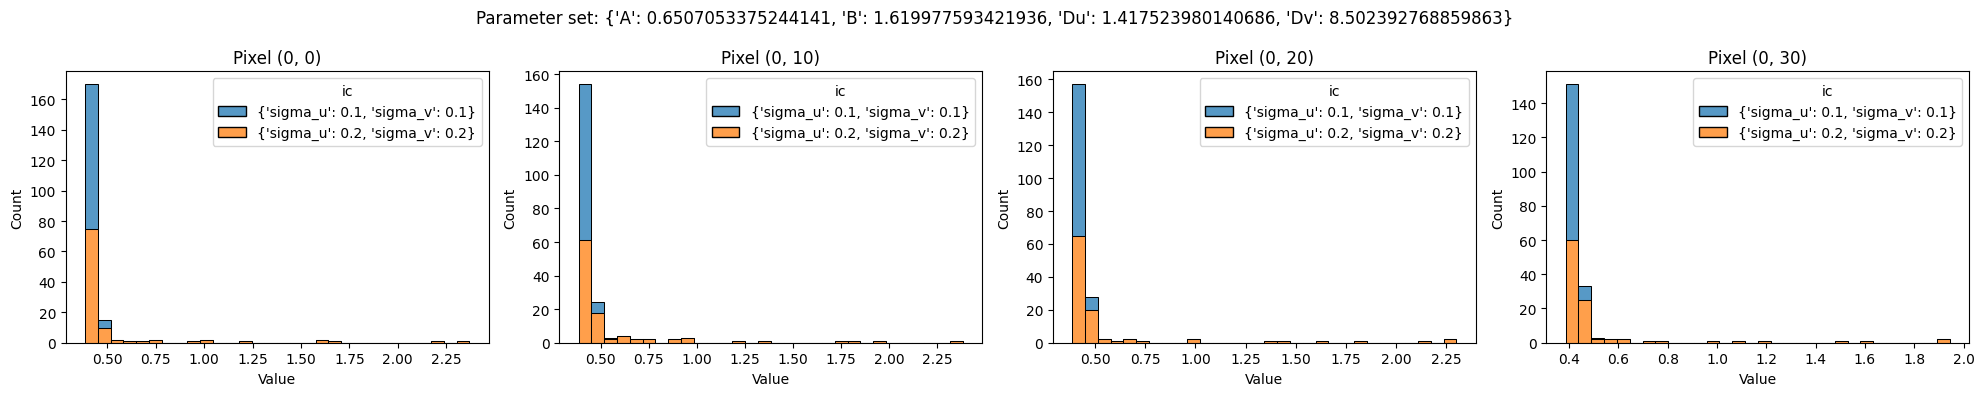

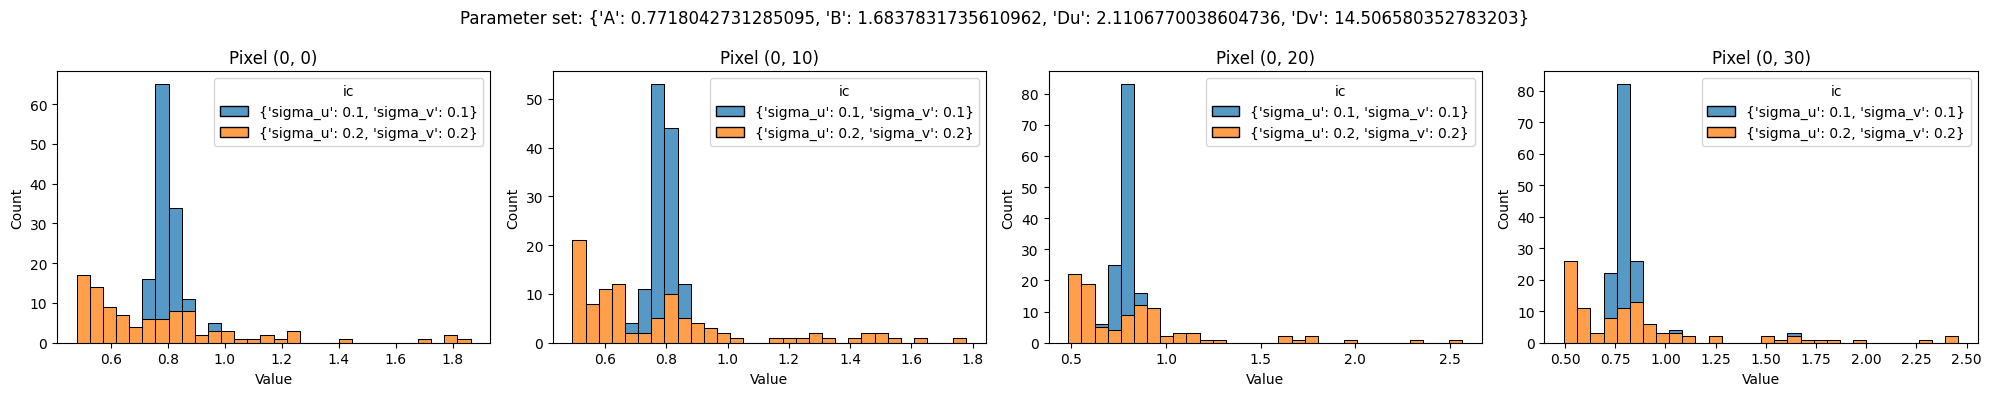

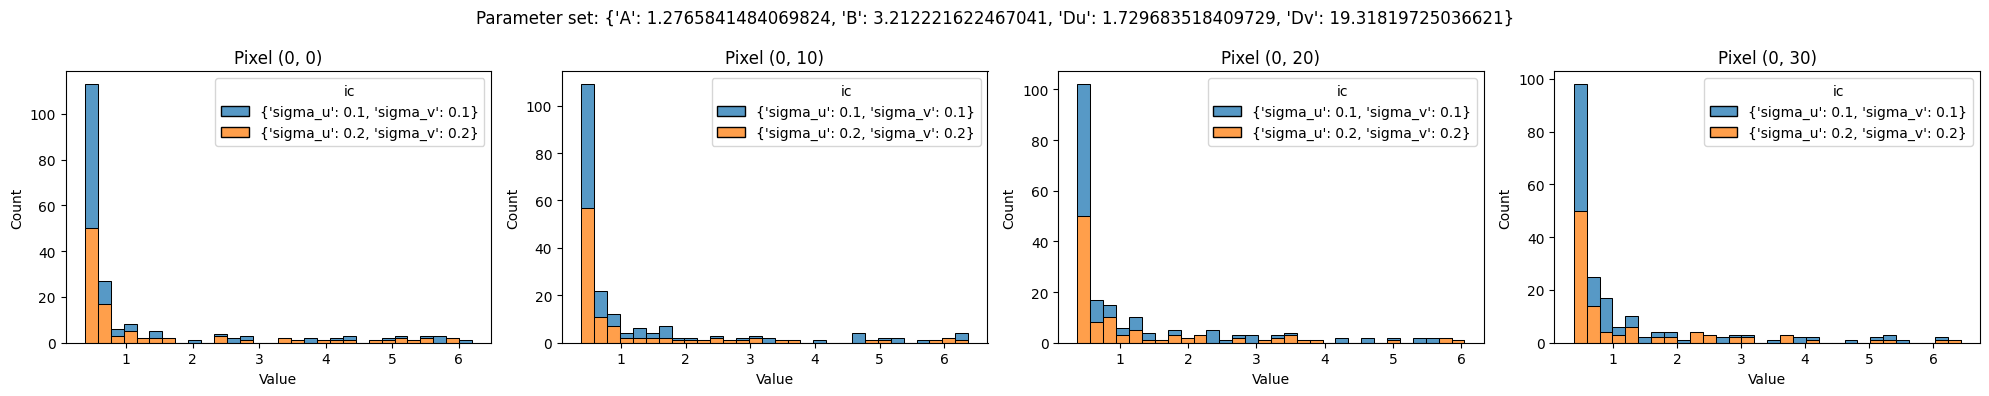

In [10]:
pixels = [(0, i) for i in range(0,40,10)]
for idx in range(5):
    plot_pixel_histograms_by_ic(df, ds, pixels, idx)